In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [2]:
# Assign processed data to data_files
cwd = os.getcwd()
data_dir = os.path.join(cwd, "data/")
data_files = [f for f in os.listdir(str(data_dir)) if f.endswith('csv')]

data_train_name = [f for f in data_files if 'TRAIN' in f]
data_test_name = [f for f in data_files if 'TEST' in f]

data_train = pd.read_csv(os.path.join(data_dir,data_train_name[0]))
data_test = pd.read_csv(os.path.join(data_dir,data_test_name[0]))


In [3]:
# Drop columns needed for classification group
boolean_col = ['highavse','lowavse','truedcr','lq']
data_train_filtered = data_train.drop(columns=boolean_col+['id'])
data_test_filtered = data_test.drop(columns=boolean_col+['id'])

# Find and Drop rows with missing values
data_train_filtered = data_train_filtered.dropna()
data_test_filtered = data_test_filtered.dropna()

# Drop irrelevant features and feature with perfect multicollinearity 
data_train_filtered = data_train_filtered.drop(columns=['tdrift50','tdrift10'])
data_test_filtered = data_test_filtered.drop(columns=['tdrift50','tdrift10'])

In [4]:
# Train Test split
X_train = data_train_filtered.drop(columns=['energylabel'])
X_test = data_test_filtered.drop(columns=['energylabel'])
y_train = data_train_filtered['energylabel']
y_test = data_test_filtered['energylabel']

# Standardizing our columns
scaler = StandardScaler()
X_train_standardized = scaler.fit_transform(X_train)
X_test_standardized = scaler.transform(X_test)

In [5]:
# Initialize lists to store MSE values
train_mse = []
test_mse = []

# Loop over n_estimators from 1 to 128
for i in [16]:
    # Initialize RandomForestRegressor with current n_estimators
    rf_model = RandomForestRegressor(
        n_estimators=i,
        random_state=42,
        verbose=2
    )
    
    # Fit the model
    rf_model.fit(X_train_standardized, y_train)
    
    # Predict on training and test sets
    y_train_pred = rf_model.predict(X_train_standardized)
    y_test_pred = rf_model.predict(X_test_standardized)
    
    # Compute MSE for training and test sets
    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))

building tree 1 of 16
building tree 2 of 16
building tree 3 of 16
building tree 4 of 16
building tree 5 of 16
building tree 6 of 16
building tree 7 of 16
building tree 8 of 16
building tree 9 of 16
building tree 10 of 16
building tree 11 of 16
building tree 12 of 16
building tree 13 of 16
building tree 14 of 16
building tree 15 of 16
building tree 16 of 16


In [6]:
print(train_mse)

[162.2601152863523]


In [7]:
print(test_mse)

[1978.706962387985]


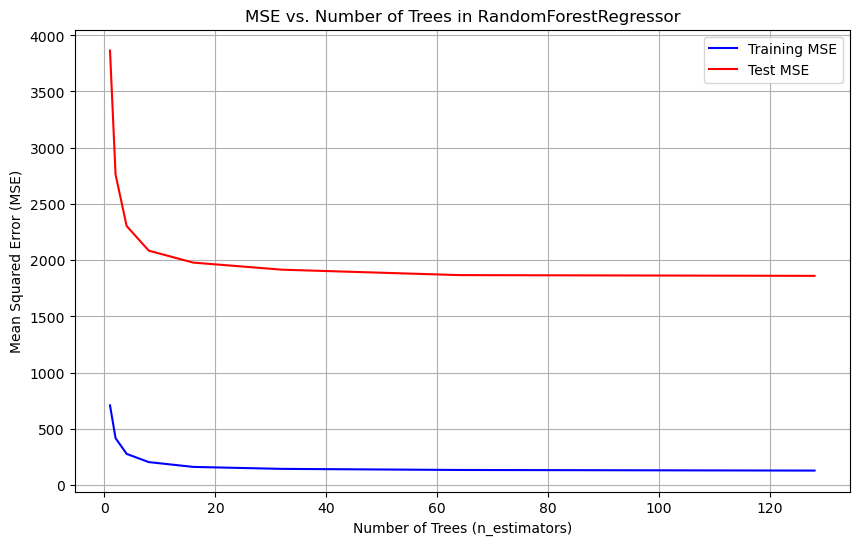

In [9]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot([1, 2, 4, 8, 16, 32, 64, 128], train_mse, label='Training MSE', color='blue', linestyle='-')
plt.plot([1, 2, 4, 8, 16, 32, 64, 128], test_mse, label='Test MSE', color='red', linestyle='-')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE vs. Number of Trees in RandomForestRegressor')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
print('Lowest MSE: ', min(test_mse))
print('Best N-Estimator: ', [1, 2, 4, 8, 16, 32, 64, 128][np.argmin(test_mse)])

Lowest MSE:  1860.811184803811
Best N-Estimator:  128


In [1]:
residuals = y_test - y_test_pred

NameError: name 'y_test' is not defined

In [14]:
np.save("RF.npy", residuals)